## Let's start the **Segmentation** process!

- Load the necessary libraries and the dataset we constructed in the previous notebook.

In [454]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [455]:
my_path = "Data"
MASTER_RFM_2016 = pd.read_csv(my_path + '\\MASTER_RFM_2016.csv')
MASTER_RFM_2015 = pd.read_csv(my_path + '\\MASTER_RFM_2015.csv')

- Create NEW variable to identify new customers

In [456]:
# New customer if seniority < 1 year
MASTER_RFM_2016["NEW"] = (MASTER_RFM_2016['SENIORITY_2016'] < 365).astype(int)
MASTER_RFM_2015["NEW"] = (MASTER_RFM_2015['SENIORITY_2015'] < 365).astype(int)

print("New customers 2016:", sum(MASTER_RFM_2016["NEW"]))
print("New customers 2015:", sum(MASTER_RFM_2015["NEW"]))

New customers 2016: 4298
New customers 2015: 3808


In 2016, we have almost 600 more new customers than in 2015.

## Determine thresholds in order to split them in low/medium/high groups
- First method: using **quantiles** (33% and 66%)
- Second method: using **KMeans clustering**

In [457]:
MASTER_RFM_2016[['CUMUL_VALUE', 'RECENCY', 'NB_VISITS']].quantile([0.30, 0.66])

,CUMUL_VALUE,RECENCY,NB_VISITS
0.30,136.0,58.0,1.0
0.66,265.0,151.0,2.0


So we can propose the following thresholds: (it's totally up to you to change the thresholds)

`MONETARY VALUE:`
- **low** if less than 136€
- **medium** if between 136€ and 265€
- **high** if more than 265€

`FREQUENCY:`
- **low** if 1 visits on the period
- **medium** if 2 visit on the period
- **high** if 3 visits or more on the period

`RECENCY:`
- **low** if last purchase more than 151 days ago
- **medium** if last purchase between 58 and 151 days ago
- **high** if last purchase less than 58 days ago

In [458]:
min_recency = 58
max_recency = 151
min_frequency = 1
max_frequency = 3
min_money = 136
max_money = 265

In [459]:
MASTER_RFM_2016["RECENCY_level"] = np.where(
    MASTER_RFM_2016["RECENCY"] > max_recency,  
    'Low',
    np.where(
        MASTER_RFM_2016["RECENCY"] < min_recency,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2016["FREQUENCY_level"] =np.where(
    MASTER_RFM_2016["NB_VISITS"] <= min_frequency,  
    'Low',
    np.where(
        MASTER_RFM_2016["NB_VISITS"] >= max_frequency,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2016["MONEY_level"] = np.where(
    MASTER_RFM_2016["CUMUL_VALUE"] < min_money,  
    'Low',
    np.where(
        MASTER_RFM_2016["CUMUL_VALUE"] > max_money,  
        'High',
        'Medium' 
        )
    )

In [460]:
MASTER_RFM_2015["RECENCY_level"] = np.where(
    MASTER_RFM_2015["RECENCY"] > max_recency,  
    'Low',
    np.where(
        MASTER_RFM_2015["RECENCY"] < min_recency,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2015["FREQUENCY_level"] =np.where(
    MASTER_RFM_2015["NB_VISITS"] < 2,  
    'Low',
    np.where(
        MASTER_RFM_2015["NB_VISITS"] > 3,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2015["MONEY_level"] = np.where(
    MASTER_RFM_2015["CUMUL_VALUE"] < 144,  
    'Low',
    np.where(
        MASTER_RFM_2015["CUMUL_VALUE"] > 273,  
        'High',
        'Medium' 
        )
    )

#### Customer Segmentation 2D using rules
- **LOW**: if low and medium or low and low
- **MEDIUM**: if medium and medium or high and low
- **HIGH**: if high and medium or high and high

In [461]:
cond_LowFM_2016 = (
    (MASTER_RFM_2016.FREQUENCY_level == 'Low') & (MASTER_RFM_2016.MONEY_level == 'Medium')
    |(MASTER_RFM_2016.FREQUENCY_level == 'Medium') & (MASTER_RFM_2016.MONEY_level == 'Low')
    | (MASTER_RFM_2016.FREQUENCY_level == 'Low')  & (MASTER_RFM_2016.MONEY_level == 'Low')   
)

cond_MediumFM_2016 = (
    (MASTER_RFM_2016.FREQUENCY_level == 'Medium') & (MASTER_RFM_2016.MONEY_level == 'Medium')
    | (MASTER_RFM_2016.FREQUENCY_level == 'High') & (MASTER_RFM_2016.MONEY_level == 'Low')
    | (MASTER_RFM_2016.FREQUENCY_level == 'Low') & (MASTER_RFM_2016.MONEY_level == 'High')
)

cond_HighFM_2016 = (
    (MASTER_RFM_2016.FREQUENCY_level == 'High') & (MASTER_RFM_2016.MONEY_level == 'Medium')
     |( MASTER_RFM_2016.FREQUENCY_level == 'Medium') & (MASTER_RFM_2016.MONEY_level == 'High')
     |( MASTER_RFM_2016.FREQUENCY_level == 'High') & (MASTER_RFM_2016.MONEY_level == 'High')   
)

cond_LowFM_2015 = (
    (MASTER_RFM_2015.FREQUENCY_level == 'Low') & (MASTER_RFM_2015.MONEY_level == 'Medium')
    |(MASTER_RFM_2015.FREQUENCY_level == 'Medium') & (MASTER_RFM_2015.MONEY_level == 'Low')
    | (MASTER_RFM_2015.FREQUENCY_level == 'Low')  & (MASTER_RFM_2015.MONEY_level == 'Low')   
)

cond_MediumFM_2015 = (
    (MASTER_RFM_2015.FREQUENCY_level == 'Medium') & (MASTER_RFM_2015.MONEY_level == 'Medium')
    | (MASTER_RFM_2015.FREQUENCY_level == 'High') & (MASTER_RFM_2015.MONEY_level == 'Low')
    | (MASTER_RFM_2015.FREQUENCY_level == 'Low') & (MASTER_RFM_2015.MONEY_level == 'High')
)

cond_HighFM_2015 = (
    (MASTER_RFM_2015.FREQUENCY_level == 'High') & (MASTER_RFM_2015.MONEY_level == 'Medium')
     |( MASTER_RFM_2015.FREQUENCY_level == 'Medium') & (MASTER_RFM_2015.MONEY_level == 'High')
     |( MASTER_RFM_2015.FREQUENCY_level == 'High') & (MASTER_RFM_2015.MONEY_level == 'High')   
)


In [462]:
MASTER_RFM_2016["FM_SEG"] = np.where(
    MASTER_RFM_2016.NEW, 
    "New Customer",
    np.where(
        cond_LowFM_2016, 
        "LowFM",
        np.where(
            cond_HighFM_2016, 
            "HighFM", 
            "MediumFM"
        )
    )
)

MASTER_RFM_2015["FM_SEG"] = np.where(
    MASTER_RFM_2015.NEW, 
    "New Customer",
    np.where(
        cond_LowFM_2015, 
        "LowFM",
        np.where(
            cond_HighFM_2015, 
            "HighFM", 
            "MediumFM"
        )
    )
)

In [463]:
MASTER_RFM_2016[["FM_SEG", "ID_INDIVIDU"]].groupby("FM_SEG").count()

,ID_INDIVIDU
FM_SEG,
HighFM,3025
LowFM,3175
MediumFM,1056
New Customer,4298


#### Final Customer Segmentation 3D using rules

In [464]:
cond_Weak_2016 = (
    (MASTER_RFM_2016.RECENCY_level == "Low") & (MASTER_RFM_2016.FM_SEG == "LowFM")
)
    
cond_Top_2016 = (
    (MASTER_RFM_2016.RECENCY_level == "High") & ( (MASTER_RFM_2016.FM_SEG == "HighFM") | (MASTER_RFM_2016.FM_SEG == "MediumFM")
    )
)

cond_Good_2016 = ((MASTER_RFM_2016.RECENCY_level == "Medium")  & ( (MASTER_RFM_2016.FM_SEG == "MediumFM") | (MASTER_RFM_2016.FM_SEG == "HighFM")
    )
)

cond_Decel_2016 = ( (MASTER_RFM_2016.RECENCY_level == "Low")  & ( (MASTER_RFM_2016.FM_SEG == "MediumFM") | (MASTER_RFM_2016.FM_SEG == "HighFM")
    )
)

cond_Small_2016 = ( (MASTER_RFM_2016.FM_SEG == "LowFM")  & ( (MASTER_RFM_2016.RECENCY_level == "Medium") | (MASTER_RFM_2016.RECENCY_level == "High")
    )
)

#2015
cond_Weak_2015 = (
    (MASTER_RFM_2015.RECENCY_level == "Low") & (MASTER_RFM_2015.FM_SEG == "LowFM")
)
cond_Top_2015 = (
    (MASTER_RFM_2015.RECENCY_level == "High") & ( (MASTER_RFM_2015.FM_SEG == "HighFM") | (MASTER_RFM_2015.FM_SEG == "MediumFM")
    )
)
cond_Good_2015 = ((MASTER_RFM_2015.RECENCY_level == "Medium")  & ( (MASTER_RFM_2015.FM_SEG == "MediumFM") | (MASTER_RFM_2015.FM_SEG == "HighFM")
    )
)
cond_Decel_2015 = ( (MASTER_RFM_2015.RECENCY_level == "Low")  & ( (MASTER_RFM_2015.FM_SEG == "MediumFM") | (MASTER_RFM_2015.FM_SEG == "HighFM")
    )
)

cond_Small_2015 =  (MASTER_RFM_2015.FM_SEG == "LowFM")  & ( (MASTER_RFM_2015.RECENCY_level == "Medium") | (MASTER_RFM_2015.RECENCY_level == "High")
    )

In [465]:
MASTER_RFM_2016["RFM_SEG"] = np.where(
    cond_Top_2016,
    'Top',
    np.where(
        cond_Good_2016,
        'Good',
        np.where(
            cond_Decel_2016,
            'Decel',
            np.where(
                cond_Small_2016,
                'Small',
                np.where(
                    cond_Weak_2016,
                    'Weak',
                    MASTER_RFM_2016.FM_SEG)
            )
        )
    )
)

MASTER_RFM_2015["RFM_SEG"] = np.where(
    cond_Top_2015,
    'Top',
    np.where(
        cond_Good_2015,
        'Good',
        np.where(
            cond_Decel_2015,
            'Decel',
            np.where(
                cond_Small_2015,
                'Small',
                np.where(
                    cond_Weak_2015,
                    'Weak',
                    MASTER_RFM_2015.FM_SEG)
            )
        )
    )
)

- Compute average value per visit

In [466]:
MASTER_RFM_2015["AVG_value_2015"] = MASTER_RFM_2015[["CUMUL_VALUE","NB_VISITS"]].apply(lambda x: x["CUMUL_VALUE"]/x["NB_VISITS"] if x["NB_VISITS"]>0 else 0, axis=1)
MASTER_RFM_2016["AVG_value_2016"] = MASTER_RFM_2016[["CUMUL_VALUE","NB_VISITS"]].apply(lambda x: x["CUMUL_VALUE"]/x["NB_VISITS"] if x["NB_VISITS"]>0 else 0, axis=1)

### Visualize the segments:
- Count of customers by segment

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\2739895982.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Customer Segments Distribution - 2016')

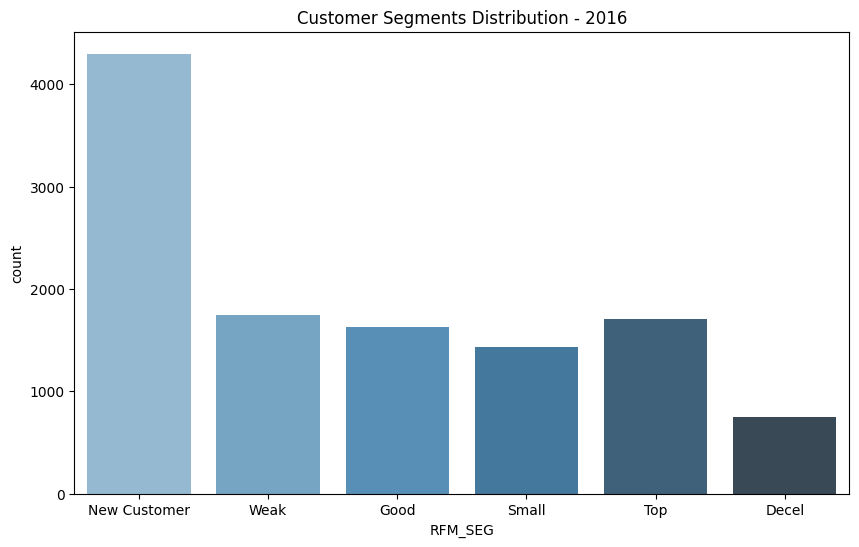

In [467]:
plt.figure(figsize=(10,6))
sns.countplot(data=MASTER_RFM_2016, x='RFM_SEG',palette='Blues_d', order=MASTER_RFM_2015['RFM_SEG'].value_counts().index)
plt.title('Customer Segments Distribution - 2016')

- Segment vs `CUMUL_VALUE, NB_VISITS, RECENCY` boxplots

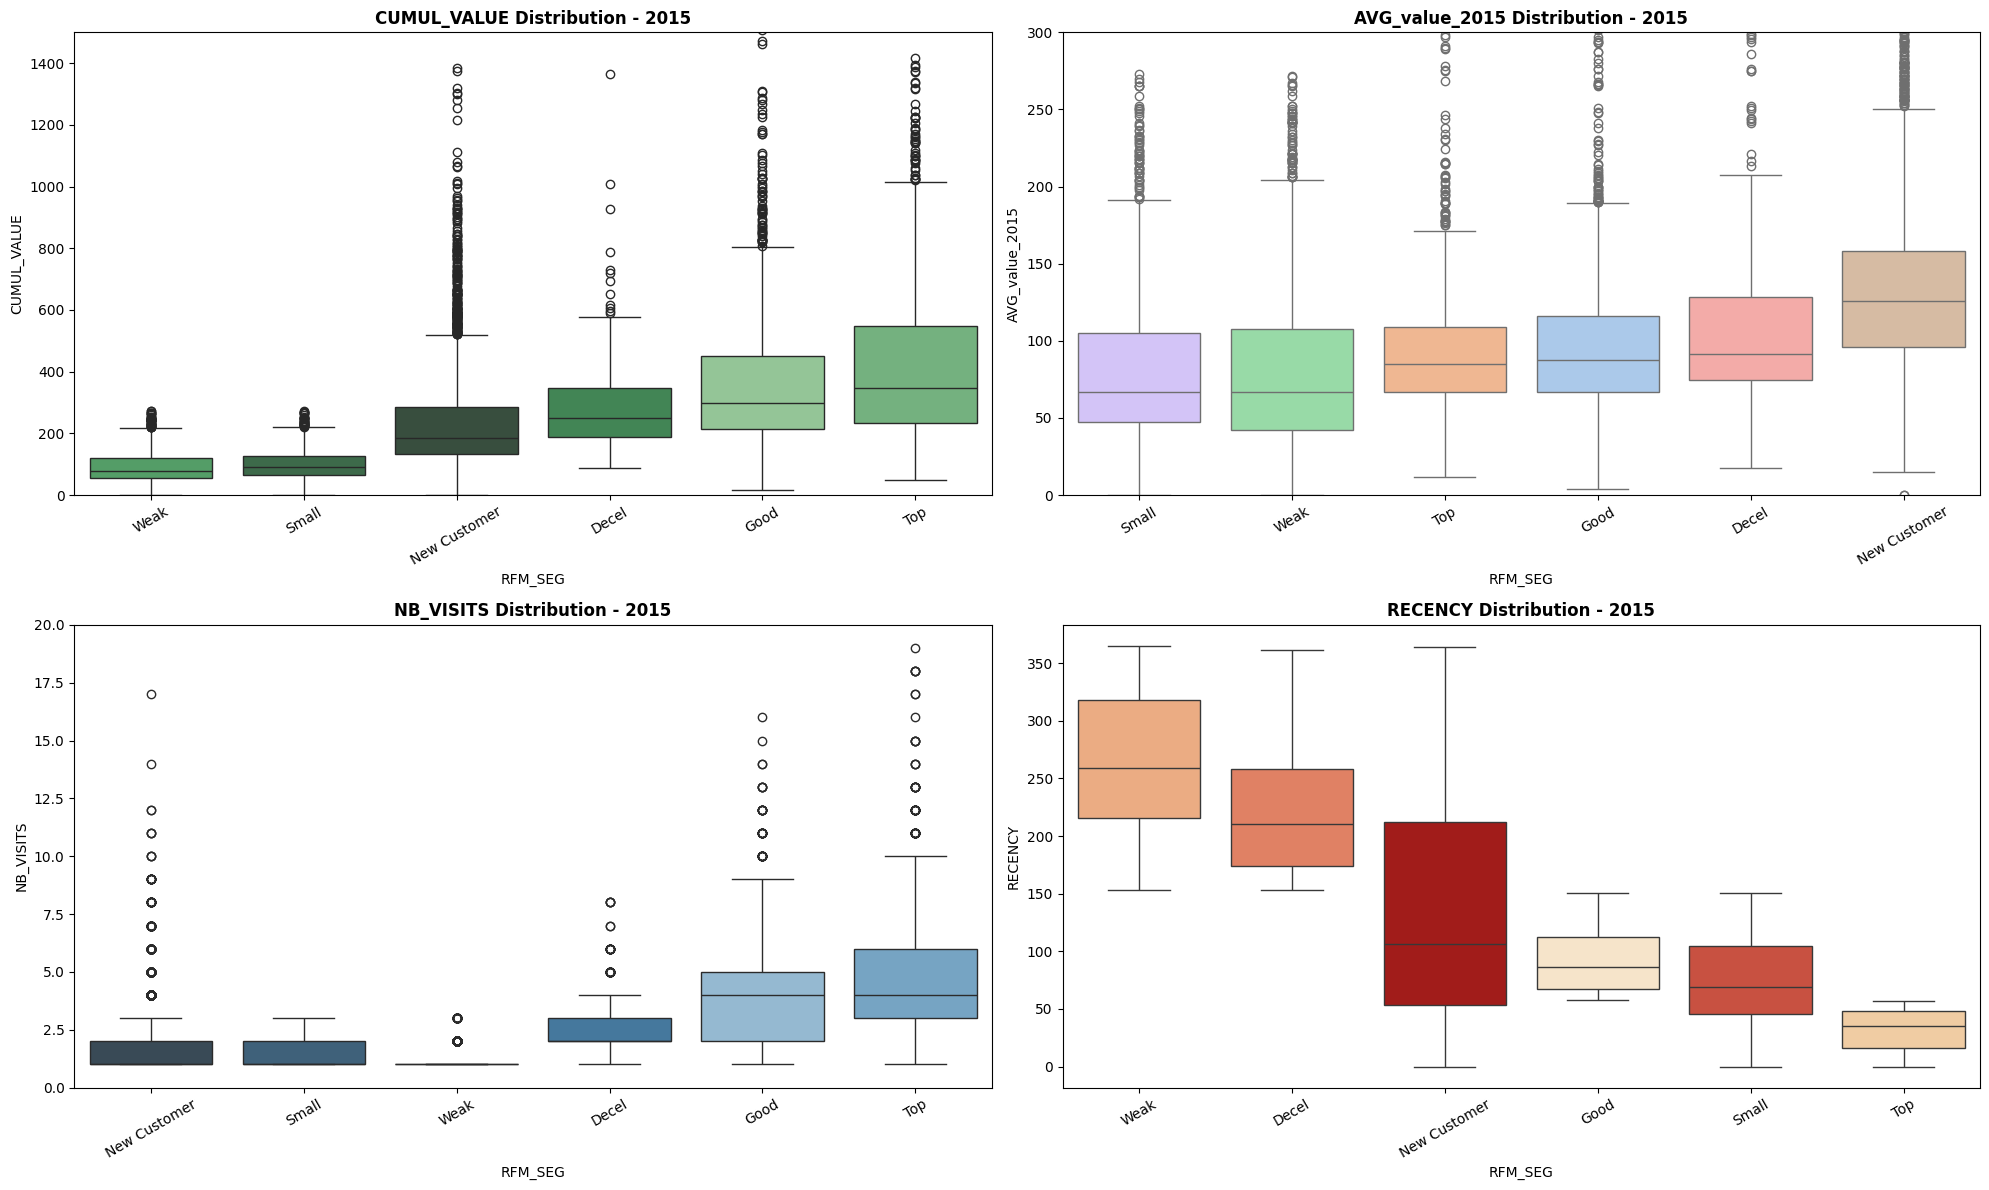

In [468]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

sns.boxplot(
    data=MASTER_RFM_2015,
    x='RFM_SEG', y='CUMUL_VALUE',
    palette='Greens_d',
    hue='RFM_SEG',
    order=MASTER_RFM_2015.groupby("RFM_SEG").CUMUL_VALUE.median().sort_values().index,
    ax=axes[0,0]
)
axes[0,0].set_ylim(0, 1500)
axes[0,0].set_title('CUMUL_VALUE Distribution - 2015', fontsize=12, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=MASTER_RFM_2015,
    x='RFM_SEG', y='AVG_value_2015',
    palette='pastel',
    hue='RFM_SEG',
    order=MASTER_RFM_2015.groupby("RFM_SEG").AVG_value_2015.median().sort_values().index,
    ax=axes[0,1]
)
axes[0,1].set_ylim(0, 300)
axes[0,1].set_title('AVG_value_2015 Distribution - 2015', fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=MASTER_RFM_2015,
    x='RFM_SEG', y='NB_VISITS',
    hue='RFM_SEG',
    palette='Blues_d',
    order=MASTER_RFM_2015.groupby("RFM_SEG").NB_VISITS.median().sort_values().index,
    ax=axes[1,0]
)
axes[1,0].set_ylim(0, 20)
axes[1,0].set_title('NB_VISITS Distribution - 2015', fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=MASTER_RFM_2015,
    x='RFM_SEG', y='RECENCY',
    palette='OrRd',
    hue='RFM_SEG',
    order=MASTER_RFM_2015.groupby("RFM_SEG").RECENCY.median().sort_values(ascending=False).index,
    ax=axes[1,1]
)
axes[1,1].set_title('RECENCY Distribution - 2015', fontsize=12, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

The basket value per visit is higher for the new customers with an average of 132.5€ per visit, the second highest is the decel with 98.5€ per visit.

In [469]:
# Group by RFM_SEG and compute both count and median
total_market_2016 = MASTER_RFM_2016["CUMUL_VALUE"].sum()
rfm_summary_2016 = (
    MASTER_RFM_2016
    .groupby("RFM_SEG")
    .agg(
        nb_individus=("ID_INDIVIDU", "count"),
        median_cumul_value=("CUMUL_VALUE", "median"),
        median_nb_visits=("NB_VISITS", "median"),
        median_recency=("RECENCY", "median"),
        pourcentage_value=("CUMUL_VALUE", lambda x: x.sum() / total_market_2016 * 100)
    )
    .reset_index()
)

In [470]:
# Group by RFM_SEG and compute both count and median
total_market_2015 = MASTER_RFM_2015["CUMUL_VALUE"].sum()
rfm_summary_2015 = (
    MASTER_RFM_2015
    .groupby("RFM_SEG")
    .agg(
        nb_individus=("ID_INDIVIDU", "count"),
        median_cumul_value=("CUMUL_VALUE", "median"),
        median_nb_visits=("NB_VISITS", "median"),
        median_recency=("RECENCY", "median"), 
        pourcentage_value=("CUMUL_VALUE", lambda x: x.sum() / total_market_2015 * 100)
    )
    .reset_index()
)
rfm_summary_2015

,RFM_SEG,nb_individus,median_cumul_value,median_nb_visits,median_recency,pourcentage_value
0,Decel,492,249.5,2.0,210.5,5.987581
1,Good,1380,300.0,4.0,86.0,21.882633
2,New Customer,3808,186.0,1.0,106.0,38.511691
3,Small,1307,92.0,1.0,69.0,5.473594
4,Top,1162,348.0,4.0,35.0,21.840705
5,Weak,1691,79.0,1.0,259.0,6.303796


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\2106241081.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




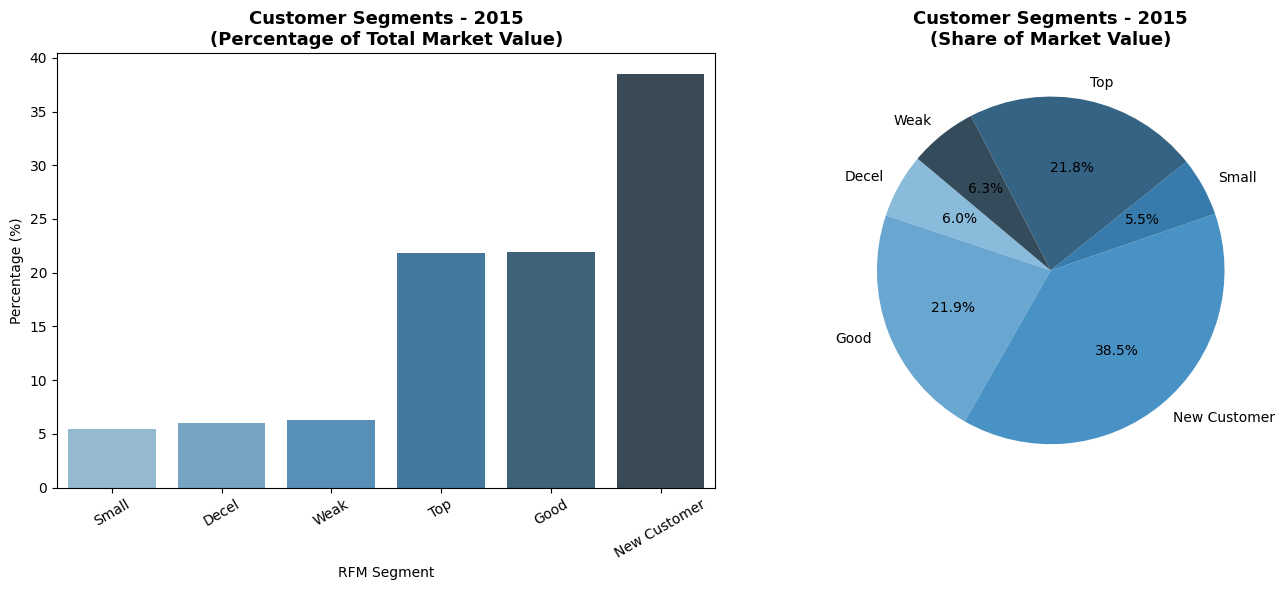

In [471]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=rfm_summary_2015.sort_values(by='pourcentage_value'),
    x='RFM_SEG',
    y='pourcentage_value',
    palette='Blues_d',
    #order=rfm_summary_2015['RFM_SEG'],
    ax=axes[0]
)
axes[0].set_title('Customer Segments - 2015\n(Percentage of Total Market Value)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('RFM Segment')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(rfm_summary_2015['pourcentage_value'], 
            labels=rfm_summary_2015['RFM_SEG'], autopct='%1.1f%%', 
            startangle=140, colors=sns.color_palette('Blues_d', n_colors=len(rfm_summary_2015)))
axes[1].set_title('Customer Segments - 2015\n(Share of Market Value)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



- New customers in 2015 are the main part of the Total Market Value $ in 2015: **38.5%**
- We want to keep them in 2016!
- If we focus on retention of top, good and new customers we cover more than **82%** of the Total Market Value in 2016

### Study the migration between 2015 and 2016 segments

- Join both datasets: Keep all the customers of 2015 too see their behavior in 2016 even if they didn't buy anything in 2016

In [472]:
#create MIGRATION_segment_with_NA which is join MASTER_RFM and MASTER_RFM_2016 with NA value takes value "No buyer 2016
MIGRATION_segment_with_NA = MASTER_RFM_2016[["ID_INDIVIDU", "RFM_SEG", "CUMUL_VALUE"]].merge(MASTER_RFM_2015[["ID_INDIVIDU", "RFM_SEG", "CUMUL_VALUE"]], on="ID_INDIVIDU", suffixes=('_2016', '_2015'), how='right')
MIGRATION_segment_with_NA["RFM_SEG_2016"] = MIGRATION_segment_with_NA["RFM_SEG_2016"].fillna("No buyer 2016")
MIGRATION_segment_with_NA["CUMUL_VALUE_2016"] = MIGRATION_segment_with_NA["CUMUL_VALUE_2016"].fillna(0)

- Look the migration matrix between 2015 and 2016 segments

In [473]:
pd.crosstab(
    MIGRATION_segment_with_NA.RFM_SEG_2015,
    MIGRATION_segment_with_NA.RFM_SEG_2016,
    normalize='index',   # normalize by column
    margins=True
).round(2) * 100

RFM_SEG_2016,Decel,Good,New Customer,No buyer 2016,Small,Top,Weak
RFM_SEG_2015,,,,,,,
Decel,11.0,17.0,0.0,30.0,12.0,16.0,13.0
Good,7.0,23.0,0.0,18.0,11.0,28.0,12.0
New Customer,7.0,13.0,0.0,46.0,9.0,12.0,13.0
Small,5.0,12.0,0.0,43.0,14.0,9.0,17.0
Top,8.0,21.0,0.0,14.0,11.0,36.0,10.0
Weak,5.0,8.0,0.0,56.0,11.0,6.0,14.0
All,7.0,15.0,0.0,39.0,11.0,16.0,13.0


In [474]:
pd.crosstab(
    MIGRATION_segment_with_NA.RFM_SEG_2015,
    MIGRATION_segment_with_NA.RFM_SEG_2016,
    normalize='index',   # normalize by column
    margins=True
).round(2) * 100

RFM_SEG_2016,Decel,Good,New Customer,No buyer 2016,Small,Top,Weak
RFM_SEG_2015,,,,,,,
Decel,11.0,17.0,0.0,30.0,12.0,16.0,13.0
Good,7.0,23.0,0.0,18.0,11.0,28.0,12.0
New Customer,7.0,13.0,0.0,46.0,9.0,12.0,13.0
Small,5.0,12.0,0.0,43.0,14.0,9.0,17.0
Top,8.0,21.0,0.0,14.0,11.0,36.0,10.0
Weak,5.0,8.0,0.0,56.0,11.0,6.0,14.0
All,7.0,15.0,0.0,39.0,11.0,16.0,13.0


> Note: Almost one half of New Customers in 2015 don't buy in 2016 !!
- 46% of New Customers in 2015 didn't buy in 2016
- 25% of New Customers in 2015 became at least a good Customers in 2016
- 7% of New Customers in 2015 became Decelerated Customers in 2016
- 31% of New Customers in 2015 became small Customers in 2016


It means there is no **RETENTION** !


In [475]:
total_market_new_2015 = MIGRATION_segment_with_NA[MIGRATION_segment_with_NA["RFM_SEG_2015"] == "New Customer"]["CUMUL_VALUE_2015"].sum()
print("Total Market Value in 2015 from New Customers in 2015:", total_market_new_2015)
total_market_new_2015_in_2016 = MIGRATION_segment_with_NA[MIGRATION_segment_with_NA["RFM_SEG_2015"] == "New Customer"]["CUMUL_VALUE_2016"].sum()
print("Total Market Value in 2016 from New Customers in 2015:", total_market_new_2015_in_2016)

Total Market Value in 2015 from New Customers in 2015: 901975.0
Total Market Value in 2016 from New Customers in 2015: 562871.0


This segment represented $901 975$ $ in 2015  and only $562 000$ $ in 2016

#### Visualize the migration with a Sankey diagram

In [476]:
# pip install plotly
import plotly.graph_objects as go
import matplotlib.cm as cm
import matplotlib.colors as mcolors

df = MIGRATION_segment_with_NA.copy()
for col in ["RFM_SEG_2015", "RFM_SEG_2016"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.upper()
        .replace({"NAN": None})
        .fillna("NO BUYER")
    )

ORDER = ["NO BUYER","WEAK","TOP","DECEL", "SMALL", "GOOD"]
present = sorted(set(df["RFM_SEG_2015"]) | set(df["RFM_SEG_2016"]))
order = [x for x in ORDER if x in present] + [x for x in present if x not in ORDER]

xtab = pd.crosstab(df["RFM_SEG_2015"], df["RFM_SEG_2016"])
xtab = xtab.reindex(index=order, columns=order, fill_value=0)


include_stays = False  
sources, targets, values, real_vals, perc = [], [], [], [], []
row_sum = xtab.sum(axis=1).replace(0, np.nan)

for i, src in enumerate(order):
    for j, dst in enumerate(order):
        v = int(xtab.iat[i, j])
        if v <= 0:
            continue
        if not include_stays and i == j:
            continue
        sources.append(i)
        targets.append(j)
        real_vals.append(v)
        p = 100.0 * v / row_sum.iat[i]
        perc.append(p if np.isfinite(p) else 0.0)

cmap = cm.get_cmap('tab20', len(order))
node_colors = [mcolors.to_hex(cmap(i)) for i in range(len(order))]

def rgba(hex_color, a=0.65):
    h = hex_color.lstrip("#")
    r,g,b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{a})"
link_colors = [rgba(node_colors[s], 0.65) for s in sources]

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        label=order,
        color=node_colors,
        pad=16, thickness=18,
        line=dict(color="rgba(0,0,0,0.3)", width=1.1),
    ),
    link=dict(
        source=sources,
        target=targets,
        value=real_vals,           
        color=link_colors,        
        customdata=np.c_[real_vals, perc],
        hovertemplate=(
            "<b>%{source.label}</b> → <b>%{target.label}</b><br>"
            "Count: %{customdata[0]}<br>"
            "Share of source: %{customdata[1]:.1f}%<extra></extra>"
        ),
    )
)])

# 
fig.update_layout(
    title=dict(
        text="RFM Migration 2015 → 2016",
        x=0.5, font=dict(size=18)
    ),
    font=dict(size=12),
    width=800, height=400,
    paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(l=10, r=10, t=60, b=10),
)
fig.show()


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\3291754880.py:43: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



In [477]:
#Look the value of the market value of the lost customers from 2015 to 2016
lost_value_2015 = MIGRATION_segment_with_NA[MIGRATION_segment_with_NA["RFM_SEG_2016"] == "No buyer 2016"]["CUMUL_VALUE_2015"].sum()

### Customer Value Gains and Losses (2015 → 2016)

In this section, we analyze which customer segments increased or decreased their overall value between 2015 and 2016.  
We will:
- Compute the change (`Δ Value`) for each customer  
- Summarize gains and losses per initial RFM segment  
- Visualize which segments contributed most to overall growth or decline


In [489]:
# Compute change in value between 2015 and 2016
df = MIGRATION_segment_with_NA.copy()
df["DELTA_VALUE"] = df["CUMUL_VALUE_2016"] - df["CUMUL_VALUE_2015"]

# Summary by initial RFM segment (2015)
delta_summary = (
    df.groupby("RFM_SEG_2015")["DELTA_VALUE"]
      .agg(["mean", "median", "count"])
      .sort_values("mean", ascending=False)
      .reset_index()
)

delta_summary


,RFM_SEG_2015,mean,median,count
0,Small,8.502678,-34.0,1307
1,Weak,-5.519811,-39.0,1691
2,Good,-87.939855,-117.0,1380
3,Decel,-88.276423,-125.5,492
4,New Customer,-89.050420,-120.0,3808
5,Top,-91.106713,-127.0,1162


##### Visualization
We can now visualize the *average change in customer value* per RFM segment in 2015.  
Positive bars indicate segments that **gained value** on average, while negative bars indicate **value loss**.


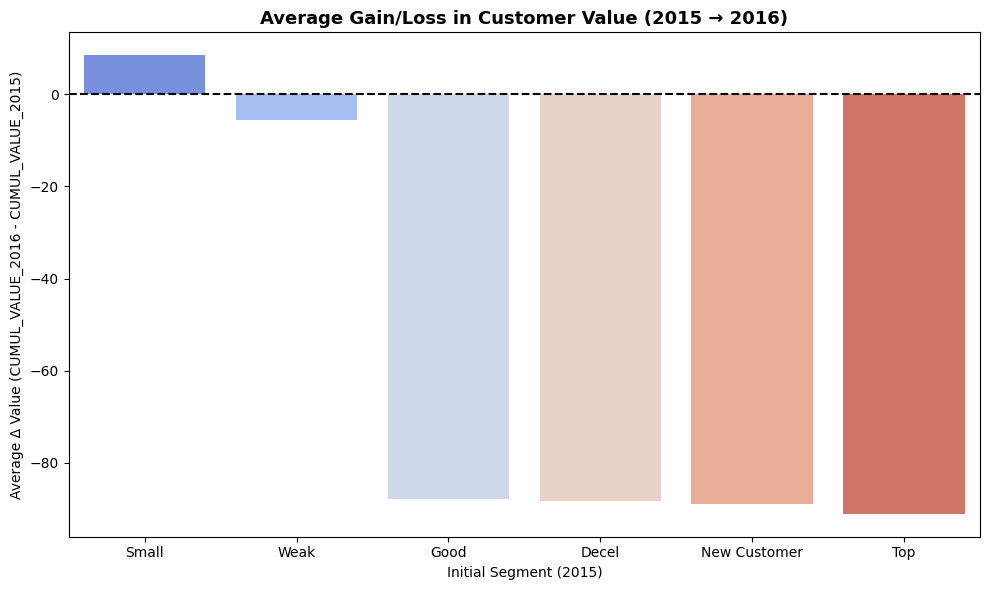

In [479]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=delta_summary,
    x="RFM_SEG_2015", y="mean",
    hue="RFM_SEG_2015",
    palette="coolwarm",
    order=delta_summary["RFM_SEG_2015"]
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Average Gain/Loss in Customer Value (2015 → 2016)", fontsize=13, fontweight="bold")
plt.ylabel("Average Δ Value (CUMUL_VALUE_2016 - CUMUL_VALUE_2015)")
plt.xlabel("Initial Segment (2015)")
plt.tight_layout()
plt.show()

###  Interpretation of the Gain/Loss Chart


- Only the **SMALL** segment displays a **positive average gain**, meaning customers in this group slightly increased their spending or engagement.  
- All other segments, especially the **GOOD, NEWS** and **TOP** segments, show **negative value changes**, indicating that their monetary contribution **declined over time**.  
- This pattern suggests that even high-value or previously loyal customers **reduced their overall activity** between 2015 and 2016.
- Such behavior may point to **saturation, reduced purchase frequency, or disengagement** from top-tier clients — an early sign of potential **loyalty erosion**.
- The focus should therefore shift to:
  - **Re-engagement strategies** for top and good-news customers.
  - **Retention campaigns** to stabilize high-value groups.
  - Understanding **why small customers increased** (e.g., new offers, pricing, or acquisition effects).

In summary, while the **SMALL** segment improved, the **general downward trend across higher RFM tiers** is a warning sign that deserves attention in future campaigns.


___
### Customer Retention, Attrition, and Upgrade Analysis

Now we evaluate how stable each segment is between 2015 and 2016:  
- **Retention rate:** % of customers staying in the same segment  
- **Attrition rate:** % moving to “NO BUYER”  
- **Upgrade rate:** % moving to higher-value segments  
This helps identify loyal, at-risk, and growing customer groups.


In [480]:
import pandas as pd
import numpy as np

# Transition matrix (row-normalized)
transition = pd.crosstab(
    df["RFM_SEG_2015"],
    df["RFM_SEG_2016"],
    normalize="index"
) * 100

# Retention rate (same segment)
transition["retention_rate"] = [
    transition.loc[s, s] if s in transition.columns else 0 for s in transition.index
]

# Attrition rate (moved to No buyer 2016)
transition["attrition_rate"] = (
    transition["No buyer 2016"] if "No buyer 2016" in transition.columns else 0
)

# upgrade rate (moved to higher segment)
order = ["No buyer 2016","Weak","New Customer","Small","Decel","Good","Top"]
rank = {seg: i for i, seg in enumerate(order)}

def upgrade_rate(row):
    seg = row.name
    if seg not in rank:
        return 0
    higher = [c for c in transition.columns if c in rank and rank[c] > rank[seg]]
    return row[higher].sum()

transition["upgrade_rate"] = transition.apply(upgrade_rate, axis=1)

# Compact summary
summary = transition[["retention_rate", "attrition_rate", "upgrade_rate"]].reset_index()
summary.head()


RFM_SEG_2016,RFM_SEG_2015,retention_rate,attrition_rate,upgrade_rate
0,Decel,10.772358,29.878049,33.739837
1,Good,23.405797,18.333333,28.043478
2,New Customer,0.078782,45.509454,41.123950
3,Small,14.078041,43.458301,25.860750
4,Top,36.402754,13.511188,0.000000


### Visualization
Let’s plot the retention, attrition, and upgrade rates for each 2015 segment.


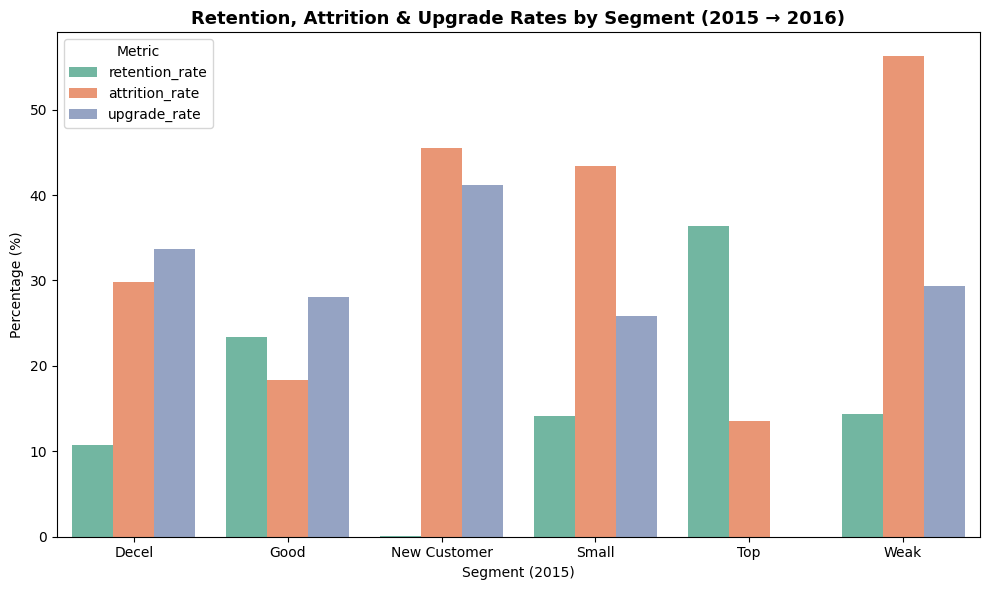

In [481]:
summary_melted = summary.melt(
    id_vars="RFM_SEG_2015",
    var_name="Metric",
    value_name="Rate"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=summary_melted,
    x="RFM_SEG_2015", y="Rate", hue="Metric",
    palette="Set2"
)
plt.title("Retention, Attrition & Upgrade Rates by Segment (2015 → 2016)",
          fontsize=13, fontweight="bold")
plt.ylabel("Percentage (%)")
plt.xlabel("Segment (2015)")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


- ### Clustering Segmentation

In [482]:
MASTER_clustering_2016.columns

Index(['ID_INDIVIDU', 'CIVILITE', 'SEXE', 'MANAGING_STORE', 'AGE_2016',
       'SENIORITY_2016', 'SHARE_MANAGING_STORE', 'NB_GIFTS', 'NB_STORES',
       'NB_LINES', 'NB_FAMILIES', 'RECENCY', 'NB_VISITS', 'CUMUL_VALUE', 'NEW',
       'AVG_value_2016'],
      dtype='object')

In [483]:
MASTER_clustering_2016[["CIVILITE", "SEXE"]]
pd.crosstab(MASTER_clustering_2016["CIVILITE"], MASTER_clustering_2016["SEXE"])

SEXE,0.0,1.0,2.0
CIVILITE,,,
0.0,2,0,0
1.0,0,86,0
2.0,0,0,4973
3.0,0,0,6493


In [484]:
MASTER_clustering_2016=MASTER_RFM_2016.copy()
MASTER_clustering_2015=MASTER_RFM_2015.copy()
#drop col : 'RFM_SEG', 'RECENCY_level', 'FREQUENCY_level', 'MONEY_level', 'FM_SEG', "PROFESSION", "CATEGORIE_PROF",
MASTER_clustering_2016=MASTER_clustering_2016.drop(columns=['RFM_SEG', 'RECENCY_level', 'FREQUENCY_level', 'MONEY_level', 'FM_SEG', "PROFESSION", "CATEGORIE_PROF","DATE_CREATION_CARTE"], errors='ignore')
MASTER_clustering_2015=MASTER_clustering_2015.drop(columns=['RFM_SEG', 'RECENCY_level', 'FREQUENCY_level', 'MONEY_level', 'FM_SEG', "PROFESSION", "CATEGORIE_PROF","DATE_CREATION_CARTE"], errors='ignore')

- Suppose we want to do clustering segmentation instead of RFM segmentation using 4 KMeans clusters.

In [485]:
MASTER_clustering_2016.head()

,ID_INDIVIDU,CIVILITE,SEXE,MANAGING_STORE,AGE_2016,SENIORITY_2016,is_Paris,is_Centre_Ville,TOP_MANAGING_STORE,NB_GIFTS,NB_STORES,NB_LINES,NB_FAMILIES,RECENCY,NB_VISITS,CUMUL_VALUE,NEW,AVG_value_2016
0,91.0,2.0,2.0,312.0,62.0,3288.0,0.0,0.0,1.0,0.0,1.0,1.0,3.0,143.0,1.0,112.0,0,112.0
1,99.0,2.0,2.0,312.0,46.0,3248.0,0.0,0.0,0.0,0.0,1.0,2.0,5.0,95.0,3.0,177.0,0,59.0
2,557.0,3.0,2.0,753.0,57.0,3397.0,1.0,0.0,1.0,7.0,1.0,3.0,7.0,65.0,4.0,272.0,0,68.0
3,1396.0,3.0,2.0,920.0,43.0,3178.0,1.0,0.0,0.0,3.0,4.0,2.0,8.0,60.0,8.0,876.0,0,109.5
4,1433.0,3.0,2.0,920.0,63.0,3199.0,1.0,0.0,1.0,3.0,1.0,2.0,5.0,41.0,4.0,322.0,0,80.5


- Build Scaled Data for clustering with: <br> 
   -   $z = (x - u) / std                                          $

In [496]:
#replace NAN in MASTER_clustering_2016["SENIORITY_2016"] by the mean 
MASTER_clustering_2016["SENIORITY_2016"] = MASTER_clustering_2016["SENIORITY_2016"].fillna(MASTER_clustering_2016["SENIORITY_2016"].mean())
MASTER_clustering_2015["SENIORITY_2015"] = MASTER_clustering_2015["SENIORITY_2015"].fillna(MASTER_clustering_2015["SENIORITY_2015"].mean())

In [500]:
#check if nan 
if MASTER_clustering_2015.isna().sum().sum() == 0:
    print("No missing values in MASTER_clustering_2015")
if MASTER_clustering_2016.isna().sum().sum() == 0:
    print("No missing values in MASTER_clustering_2016")

No missing values in MASTER_clustering_2015
No missing values in MASTER_clustering_2016


In [501]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#exclude ID_INDIVIDU and apply scaling (x-mu)/std 
scaled_data_2016 = scaler.fit_transform(MASTER_clustering_2016.drop(columns=['ID_INDIVIDU']))
scaled_data_2015 = scaler.fit_transform(MASTER_clustering_2015.drop(columns=['ID_INDIVIDU']))

### Choosing the number of clusters

Based on the three indicators:

- The **Elbow method** shows where additional clusters bring little improvement.  
- The **Silhouette score** indicates how well customers are separated (the higher, the better).  
- The **Davies-Bouldin index** (D-index) measures intra/inter-cluster similarity (the lower, the better).

Select the value of **k** that balances these criteria — usually where:
- Inertia flattens,  
- Silhouette is relatively high, and  
- D-index is near its minimum.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

def find_best_k(scaled_data, year, max_k=10, plot=True):
    """
    Evaluate KMeans clustering for k = 2..max_k
    Returns the best k based on silhouette + Davies-Bouldin index.
    """

    inertia, silhouette, d_index = [], [], []
    K = range(2, max_k + 1)

    # Compute metrics
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(scaled_data)
        inertia.append(kmeans.inertia_)
        silhouette.append(silhouette_score(scaled_data, labels))
        d_index.append(davies_bouldin_score(scaled_data, labels))

    # Normalize scores to comparable scales ---
    sil_norm = (np.array(silhouette) - np.min(silhouette)) / (np.max(silhouette) - np.min(silhouette))
    db_norm  = (np.max(d_index) - np.array(d_index)) / (np.max(d_index) - np.min(d_index))  # reversed (lower is better)

    # Combined score (weighted average) ---
    combined_score = 0.5 * sil_norm + 0.5 * db_norm  # weight silhouette more strongly

    best_k = K[np.argmax(combined_score)]

    # Plot metrics
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].plot(K, inertia, 'o-', color='steelblue')
        axes[0].set_title(f'Elbow (Inertia) - {year}')
        axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

        axes[1].plot(K, silhouette, 'o-', color='orange')
        axes[1].set_title(f'Silhouette - {year}')
        axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

        axes[2].plot(K, d_index, 'o-', color='green')
        axes[2].set_title(f'Davies-Bouldin Index - {year}')
        axes[2].set_xlabel('k'); axes[2].set_ylabel('DB Index')

        plt.suptitle(f"K-Means Evaluation — {year}\nBest k = {best_k}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

    print(f"✅ Best number of clusters for {year}: {best_k}")
    return best_k


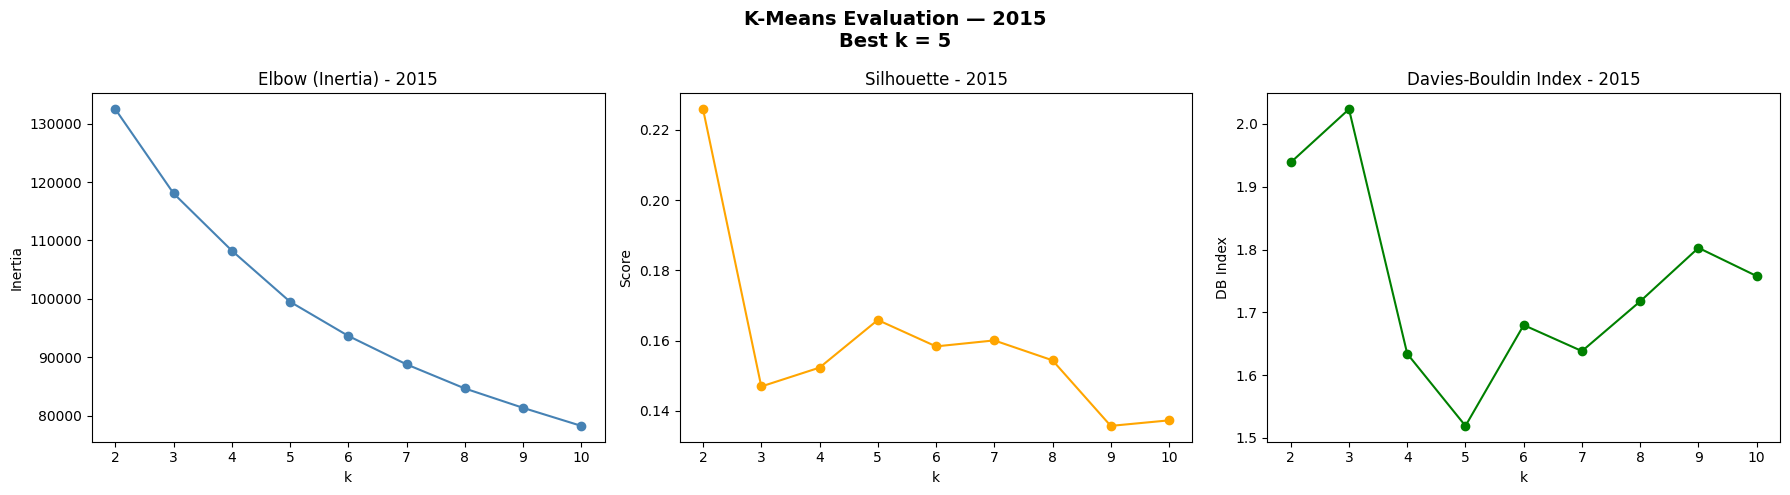

✅ Best number of clusters for 2015: 5


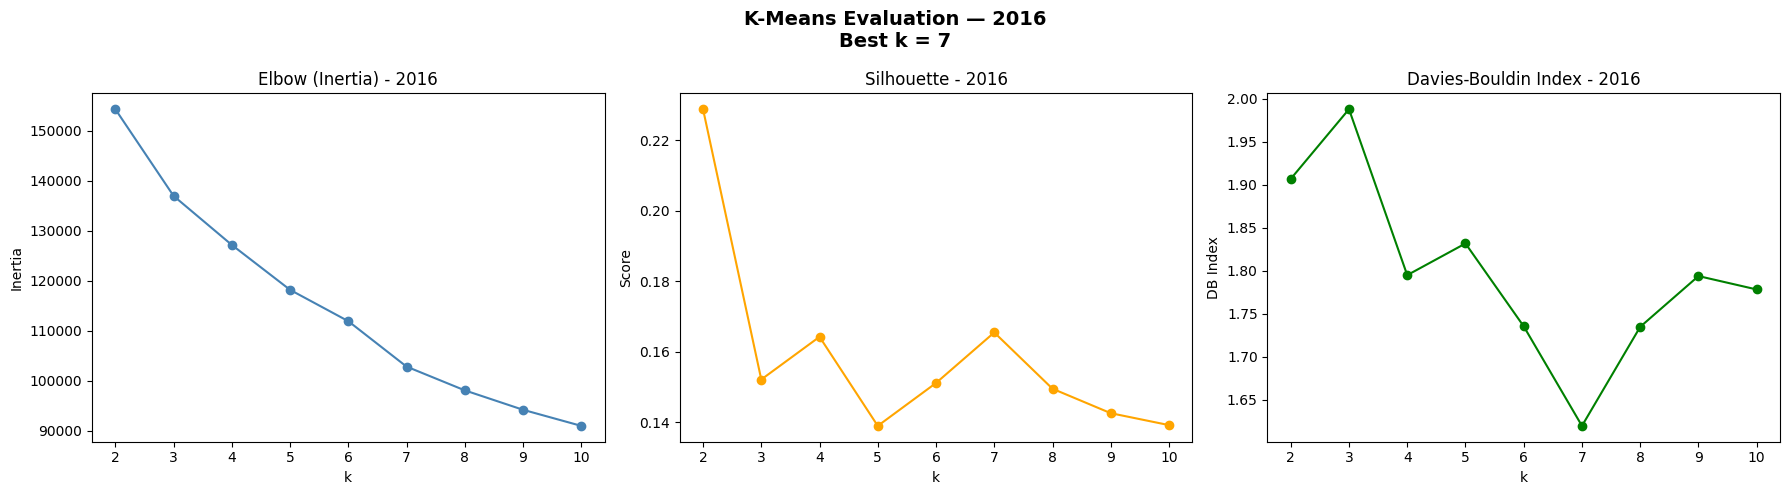

✅ Best number of clusters for 2016: 7


In [507]:
best_k_2015 = find_best_k(scaled_data_2015, "2015", max_k=10)
best_k_2016 = find_best_k(scaled_data_2016, "2016", max_k=10)

#### Based on the combined metrics, the best K is
- 5 clusters for years 2015
- 7 clusters for years 2016

We will arbitrarily choose to keep 5 clusters for both years to be able to compare them.

--- 
-   Apply clustering with K=5 for both years

In [509]:
# --- Set number of clusters ---
k = 5

# --- Fit K-Means ---
kmeans_2015 = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_2016 = KMeans(n_clusters=k, random_state=42, n_init=10)

# --- Assign cluster labels ---
MASTER_clustering_2015["cluster"] = kmeans_2015.fit_predict(scaled_data_2015)
MASTER_clustering_2016["cluster"] = kmeans_2016.fit_predict(scaled_data_2016)

print("Cluster counts (2015):")
print(MASTER_clustering_2015["cluster"].value_counts().sort_index(), "\n")

print("Cluster counts (2016):")
print(MASTER_clustering_2016["cluster"].value_counts().sort_index())


Cluster counts (2015):
cluster
0     625
1    3209
2    1723
3    4216
4      67
Name: count, dtype: int64 

Cluster counts (2016):
cluster
0    3430
1    3864
2    2359
3    1813
4      88
Name: count, dtype: int64


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\24557332.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\24557332.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\24557332.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




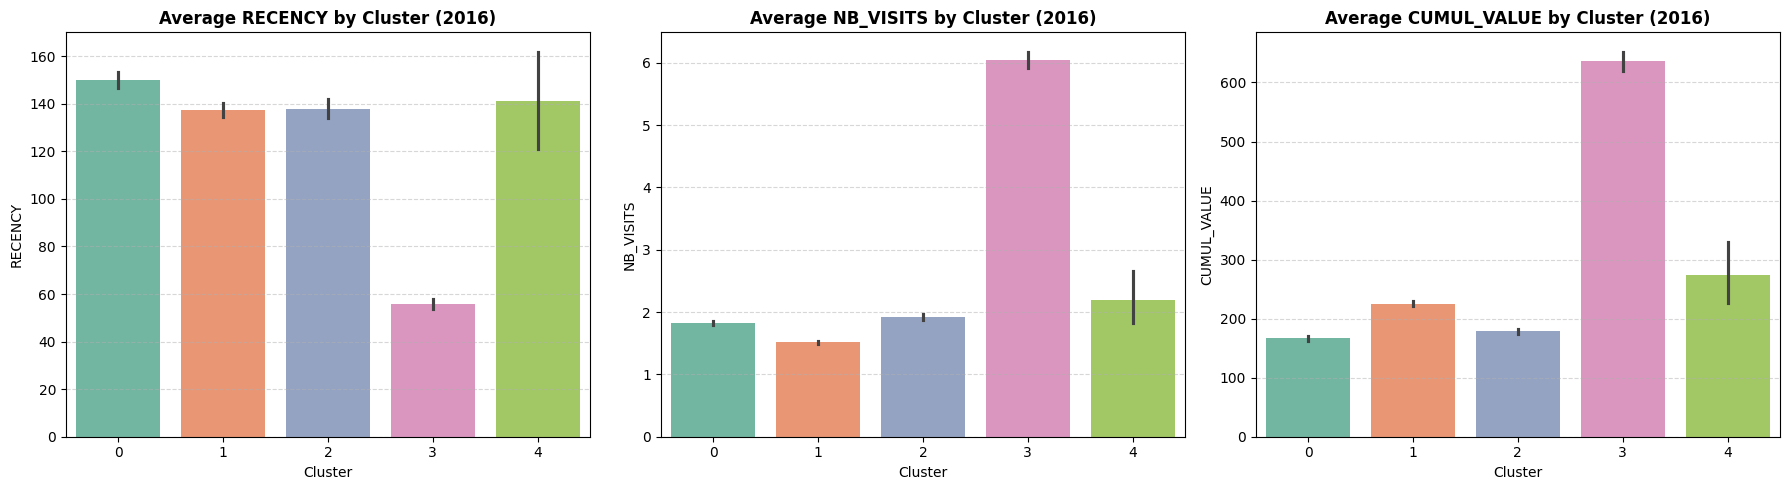

In [540]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- 1) Bar plots for each variable ----
rfm_vars = ["RECENCY", "NB_VISITS", "CUMUL_VALUE"]  # adapt names if needed

fig, axes = plt.subplots(1, len(rfm_vars), figsize=(18,5))
palette = sns.color_palette("Set2", n_colors=k)

for i, var in enumerate(rfm_vars):
    sns.barplot(
        data=MASTER_clustering_2016,
        x="cluster", y=var,
        palette=palette, ax=axes[i],
        estimator=np.mean
    )
    axes[i].set_title(f"Average {var} by Cluster (2016)", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(var)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [541]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select relevant variables for profiling
profile_vars = [
    "RECENCY", "NB_VISITS", "CUMUL_VALUE",
    "AGE_2016", "is_Paris", "SENIORITY_2016", "NEW", "AVG_value_2016", "NB_GIFTS", "NB_STORES", "NB_LINES", "NB_FAMILIES","CIVILITE", "SEXE"
]

# Group by cluster and compute means
cluster_profile = (
    MASTER_clustering_2016.groupby("cluster")[profile_vars]
    .median() #change by mean also results are similar
    .round(2)
)
#cluster 0,2,4 for
cluster_profile


,RECENCY,NB_VISITS,CUMUL_VALUE,AGE_2016,is_Paris,SENIORITY_2016,NEW,AVG_value_2016,NB_GIFTS,NB_STORES,NB_LINES,NB_FAMILIES,CIVILITE,SEXE
cluster,,,,,,,,,,,,,,
0,133.0,1.0,142.0,46.0,0.0,1064.0,0.0,85.00,0.0,1.0,1.0,3.0,3.0,2.0
1,115.0,1.0,189.0,44.0,0.0,153.0,1.0,144.17,1.0,1.0,1.0,4.0,3.0,2.0
2,118.0,2.0,160.0,43.0,0.0,1117.0,0.0,87.00,0.0,1.0,1.0,3.0,2.0,2.0
3,42.0,5.0,544.0,45.0,0.0,958.0,0.0,100.25,3.0,2.0,3.0,8.0,3.0,2.0
4,106.0,2.0,212.0,46.0,0.0,351.5,1.0,110.00,1.0,1.0,1.0,3.5,1.0,1.0


> ###  Remarks on Cluster Interpretation

- **Cluster 1:** Mainly composed of **new customers** with **low purchase frequency** and **medium recency** and **cumulative value**, but showing a **high average transaction value**. These customers spend more per visit, despite limited engagement.

- **Cluster 3:** Represents the **most valuable and loyal customers** — characterized by **high frequency**, **low recency**, and **high cumulative value**. Their average purchase value is moderate, but they stand out by having the **highest number of gifts, stores visited, product lines, and families purchased**.

- **Cluster 4:** Consists primarily of **male customers** with **low recency**, **medium frequency**, and **relatively high cumulative value**. This segment indicates a stable and engaged male clientele with steady purchasing behavior. It's composed of half of new customers.

- **Clusters 0 and 2:** These two clusters share similar profiles — both with **low frequency** and **low cumulative value**.  
  However:
  - **Cluster 2** has **lower recency**, indicating slightly more recent activity.  
  - **Cluster 0** contains **older customers**, while **Cluster 2** is composed mainly of **younger women** (and not married).  
  Together, they represent **low-engagement customer groups** differentiated primarily by age and gender.



--- 
#### Visualize Cluster Profiles with Radar Charts

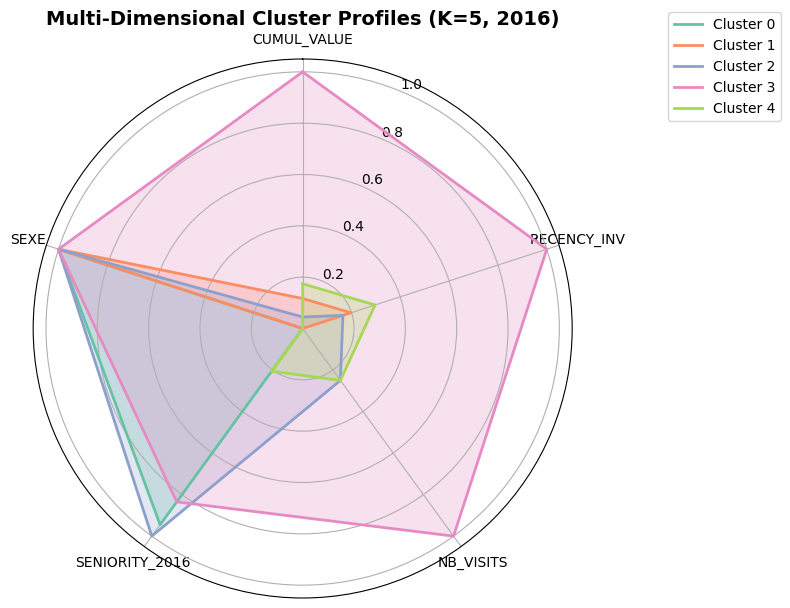

In [538]:
#Inverse RECENCY for better interpretation (lower is better)
cluster_profile["RECENCY_INV"] = cluster_profile["RECENCY"].max() - cluster_profile["RECENCY"]
# Normalize the cluster profiles for comparison (0–1 scale)
variables_plot=["CUMUL_VALUE", "RECENCY_INV", "NB_VISITS","SENIORITY_2016","SEXE"]
norm_profile = (cluster_profile[variables_plot] - cluster_profile[variables_plot].min()) / (cluster_profile[variables_plot].max() - cluster_profile[variables_plot].min())
variables_plot = norm_profile.columns.tolist()
num_vars = len(variables_plot)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for i, (cluster, row) in enumerate(norm_profile.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=palette[i], linewidth=2, label=f"Cluster {cluster}")
    ax.fill(angles, values, color=palette[i], alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), variables_plot)
ax.set_title("Multi-Dimensional Cluster Profiles (K=5, 2016)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))
plt.show()
